# Building a CNN Model for Image Classification Assignment
## By Gladwin Thomas
## DS09

### Objective
The goal of this assignment is to design, implement, and evaluate a Convolutional Neural
Network (CNN) model using a real-world dataset. Students will gain hands-on experience in
data preprocessing, CNN architecture design, training, evaluation, and model interpretation.

## Tasks
## Part A: Data Understanding and Preprocessing
1. Load the dataset and explore its structure (number of classes, sample images, image
sizes).
2. Perform data preprocessing steps:

- Resize all images to a common size (e.g., 150×150).
- Normalize pixel values.
- Split dataset into train, validation, and test sets.
- Apply data augmentation (rotation, flip, zoom, shift, etc.) to improve generalization.

### Import required libraries

In [1]:
# Import required libraries
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

I0000 00:00:1782391116.535012   15869 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Define Dataset Path

In [2]:
# Dataset paths
train_dir = "data/seg_train"
test_dir = "data/seg_test"

### Explore Dataset Structure

In [3]:
# Get class names
class_names = sorted(os.listdir(train_dir))

print("Classes in Dataset:")
print(class_names)

print("\nNumber of Classes:", len(class_names))

Classes in Dataset:
['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

Number of Classes: 6


In [4]:
# Number of Images per Class
print("Number of Images in Each Class\n")

total_images = 0

for cls in class_names:
    class_path = os.path.join(train_dir, cls)
    num_images = len(os.listdir(class_path))
    total_images += num_images

    print(f"{cls:12s}: {num_images}")

print("\nTotal Training Images:", total_images)

Number of Images in Each Class

buildings   : 2191
forest      : 2271
glacier     : 2404
mountain    : 2512
sea         : 2274
street      : 2382

Total Training Images: 14034


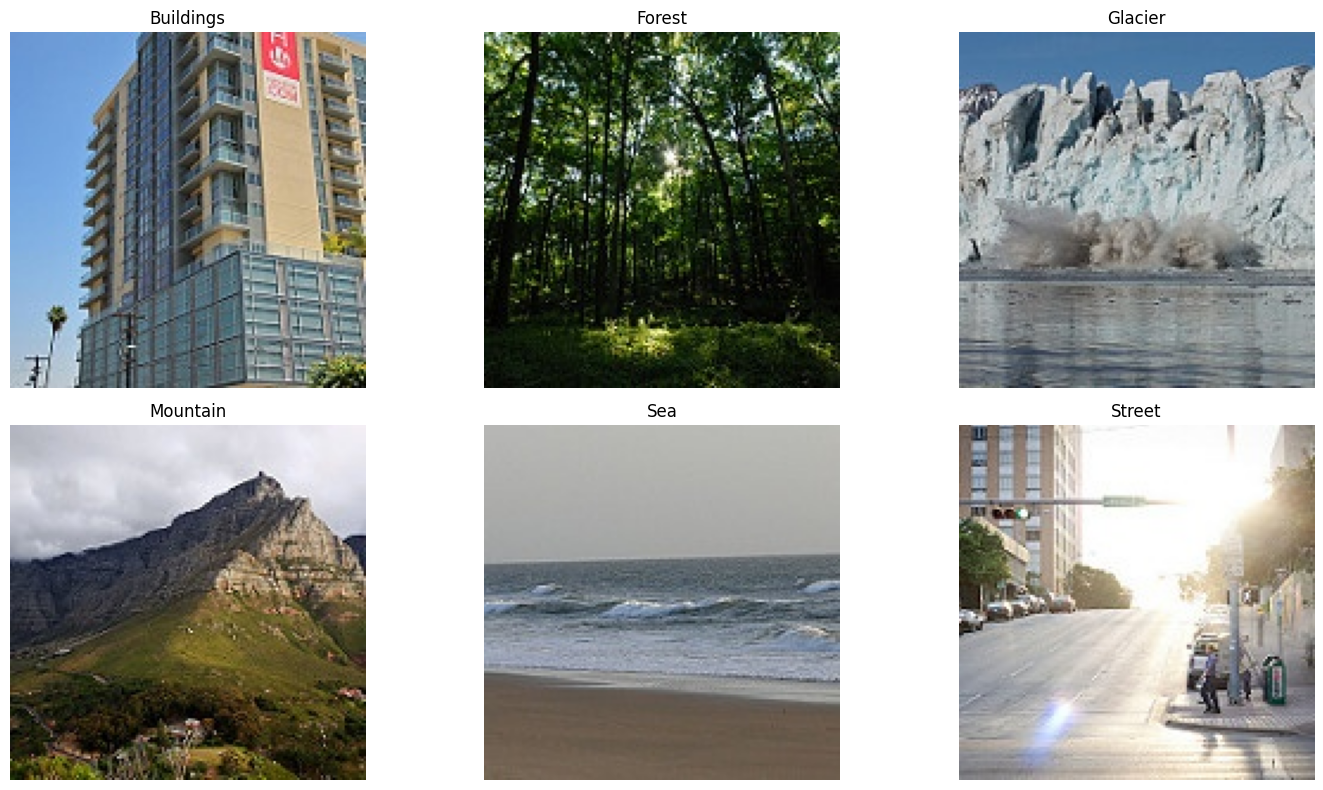

In [5]:
# Display Sample Images
plt.figure(figsize=(15,8))

for i, cls in enumerate(class_names):

    class_path = os.path.join(train_dir, cls)

    image_name = random.choice(os.listdir(class_path))

    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(2,3,i+1)
    plt.imshow(image)
    plt.title(cls.capitalize())
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
# Explore Image Sizes
image_sizes = []

for cls in class_names:

    class_path = os.path.join(train_dir, cls)

    sample_images = os.listdir(class_path)[:20]

    for img in sample_images:

        image = Image.open(os.path.join(class_path, img))

        image_sizes.append(image.size)

print("Sample Image Sizes:\n")

for size in image_sizes[:10]:
    print(size)

Sample Image Sizes:

(150, 150)
(150, 150)
(150, 150)
(150, 150)
(150, 150)
(150, 150)
(150, 150)
(150, 150)
(150, 150)
(150, 150)


In [8]:
# Find unique sizes
unique_sizes = set(image_sizes)

print("Unique Image Sizes Found:")
print(unique_sizes)

Unique Image Sizes Found:
{(150, 150)}


In [9]:
# Set image size and batch size
IMAGE_SIZE = (150,150)

BATCH_SIZE = 32

### Data Augmentation

In [10]:
# Using image data generator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.20
)

In [11]:
# Validation Generator
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20
)

In [12]:
# Test Generator
test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [13]:
# Create Training Dataset
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True

)

Found 11230 images belonging to 6 classes.


In [14]:
# Create Validation Dataset
validation_generator = validation_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 2804 images belonging to 6 classes.


In [15]:
# Create Test Dataset
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 3000 images belonging to 6 classes.


In [16]:
print("Training Samples :", train_generator.samples)
print("Validation Samples :", validation_generator.samples)
print("Testing Samples :", test_generator.samples)

Training Samples : 11230
Validation Samples : 2804
Testing Samples : 3000


### Display One Batch After Preprocessing

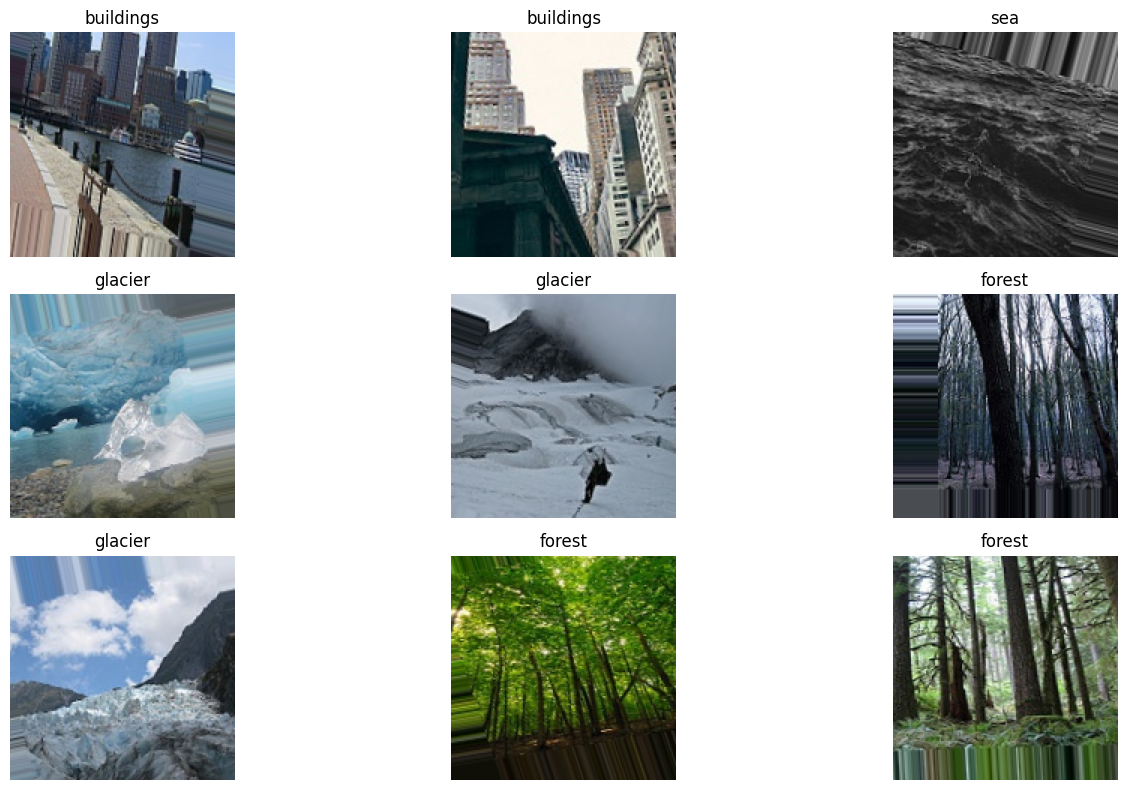

In [17]:
images, labels = next(train_generator)
plt.figure(figsize=(15,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()

### Verify Image Shape and Pixel Range

In [18]:
print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)
print("Minimum Pixel Value :", images.min())
print("Maximum Pixel Value :", images.max())

Image Batch Shape : (32, 150, 150, 3)
Label Batch Shape : (32, 6)
Minimum Pixel Value : 0.0
Maximum Pixel Value : 1.0


## Part B: CNN Model Development

### Import Required Libraries

In [19]:
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

## Build the CNN Model

### The CNN architecture consists of:

- 3 Convolutional Layers
- ReLU Activation Function
- Max Pooling Layers
- Fully Connected (Dense) Layers
- Dropout Layer
- Softmax Output Layer

In [20]:
model = Sequential([

    # Input Layer
    Input(shape=(150,150,3)),
    
    # First Convolution Block
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
    ),

    MaxPooling2D(pool_size=(2,2)),

    # Second Convolution Block
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    ),

    MaxPooling2D(pool_size=(2,2)),

    # Third Convolution Block
    Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation='relu'
    ),

    MaxPooling2D(pool_size=(2,2)),

    # Flatten Feature Maps
    Flatten(),

    # Fully Connected Layer
    Dense(
        units=256,
        activation='relu'
    ),

    # Dropout Layer
    Dropout(0.5),

    # Output Layer
    Dense(
        units=6,
        activation='softmax'
    )
])

W0000 00:00:1782391153.881384   15869 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [21]:
# Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,470,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,564,998 (36.49 MB)

 Trainable params: 9,564,998 (36.49 MB)

 Non-trainable params: 0 (0.00 B)

### Compile the Model

In [22]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Train the CNN Model

In [ ]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
)

Epoch 1/10


I0000 00:00:1782391155.033824   15869 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


351/351 ━━━━━━━━━━━━━━━━━━━━ 407s 1s/step - accuracy: 0.5093 - loss: 1.2410 - val_accuracy: 0.6255 - val_loss: 0.9690
Epoch 2/10
147/351 ━━━━━━━━━━━━━━━━━━━━ 4:17 1s/step - accuracy: 0.5751 - loss: 1.0645

### Plot Training and Validation Accuracy

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)
plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### Plot Training and Validation Loss

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

### Save the model

In [ ]:
model.save("intel_scene_classifier.keras")

print("Model saved successfully.")

## Part C: Model Evaluation and Interpretation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

### Evaluate the Model on the Test Set

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy*100:.2f}%")

### Predict Test Images

In [ ]:
# Reset generator before prediction
test_generator.reset()

# Predict probabilities
predictions = model.predict(test_generator, verbose=1)

# Predicted class indices
predicted_classes = np.argmax(predictions, axis=1)

# True class indices
true_classes = test_generator.classes

# Class labels
class_labels = list(test_generator.class_indices.keys())

### Calculate Overall Accuracy

In [ ]:
accuracy = accuracy_score(true_classes, predicted_classes)

print(f"\nOverall Test Accuracy : {accuracy*100:.2f}%")

### Generate Classification Report


In [ ]:
report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_labels
)

print("Classification Report\n")
print(report)

### Generate Confusion Matrix

In [ ]:
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

print(cm)

### Visualize Confusion Matrix

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.show()

### Visualize Predictions for 10 Random Test Images

In [ ]:
import random

# Reset generator
test_generator.reset()

# Load all test images
test_images, test_labels = next(test_generator)

# Predict on batch
predictions = model.predict(test_images)

predicted_labels = np.argmax(predictions, axis=1)

actual_labels = np.argmax(test_labels, axis=1)

# Select 10 random images
indices = random.sample(range(len(test_images)), 10)

plt.figure(figsize=(18,8))

for i, idx in enumerate(indices):

    plt.subplot(2,5,i+1)

    plt.imshow(test_images[idx])

    actual = class_labels[actual_labels[idx]]

    predicted = class_labels[predicted_labels[idx]]

    color = "green" if actual == predicted else "red"

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}",
        color=color,
        fontsize=10
    )

    plt.axis("off")

plt.tight_layout()

plt.show()